<a href="https://colab.research.google.com/github/sandhiyasudha/machine-learning-project-sandhiya/blob/main/5a_sandhiya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student_placement_career_success_dataset.csv to student_placement_career_success_dataset.csv


Cluster Centroids:
[[ 0.25797519  0.10773459  1.04619958  1.09401866  0.11006436  0.06924004]
 [ 0.52233448  0.46852644 -0.50570599 -0.49760542  0.41331189  0.29652473]
 [-0.77536732 -0.58850927 -0.37046384 -0.4203961  -0.53215419 -0.37337407]]

Number of students in each cluster:
Cluster 1 : 7401
Cluster 2 : 9044
Cluster 3 : 8555


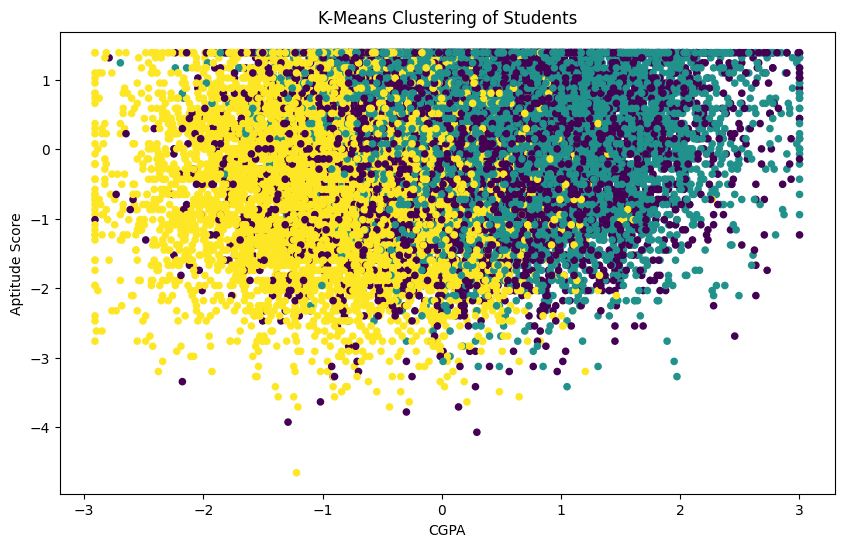

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv("student_placement_career_success_dataset.csv")

# Select career-related features
X = data[['cgpa',
          'DSA_problems_solved',
          'development_projects_count',
          'internships_completed',
          'communication_skills',
          'aptitude_score']].values

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# K-Means Clustering
def k_means(X, k, max_iters=100):

    # Randomly select initial centroids
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]

    for _ in range(max_iters):

        # Assign each point to nearest centroid
        distances = np.linalg.norm(
            X[:, np.newaxis] - centroids, axis=2
        )

        clusters = np.argmin(distances, axis=1)

        # Calculate new centroids
        new_centroids = np.array([
            X[clusters == j].mean(axis=0)
            for j in range(k)
        ])

        # Check convergence
        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return clusters, centroids


# Run K-Means
np.random.seed(42)
clusters, centroids = k_means(X, k=3)

# Display cluster information
print("Cluster Centroids:")
print(centroids)

print("\nNumber of students in each cluster:")
for i in range(3):
    print("Cluster", i + 1, ":", np.sum(clusters == i))

# Plot clusters using CGPA and Aptitude Score
plt.figure(figsize=(10, 6))

plt.scatter(
    X[:, 0],
    X[:, 5],
    c=clusters,
    cmap='viridis',
    s=20
)

plt.title("K-Means Clustering of Students")
plt.xlabel("CGPA")
plt.ylabel("Aptitude Score")
plt.show()